## **Project (2) Quanto European Option Pricing**
### Consolidated Notebook: Analytical, Monte Carlo, and PDE Methods

**QFGB8960 Advanced C++ for Finance - Spring 2026**

Covers:
- Three pricing engines: `qf.qEuroBS`, `qf.qEuroBSMC`, `qf.qEuroBSPDE`
- Convergence validation for MC and PDE
- **Question 1**: Quanto call-put parity — derivation + numerical check
- **Question 2**: Effect of asset-FX correlation ρ on option prices


In [1]:
import qflib as qf
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy.stats import norm

plt.style.use('ggplot')

print("qflib version: {0}".format(qf.version()))
print("pid: {0}".format(os.getpid()))

qflib version: 1.2.0-debug
pid: 6916


#### **Market Setup**

| Parameter | Symbol | Value |
|-----------|--------|-------|
| Spot | S | 100 |
| Strike (base) | K | 100 |
| Expiry | T | 1.0 yr |
| Domestic rate | r_d | 5% |
| Foreign rate | r_f | 3% |
| Dividend yield | q | 2% |
| Asset vol | σ_S | 20% |
| FX vol | σ_Q | 15% |
| Correlation (base) | ρ | 0.30 |


In [ ]:
qf.mktClear()

rd      = 0.05
rf      = 0.03
q_div   = 0.02
T       = 1.0
sigma_S = 0.20
sigma_Q = 0.15
rho     = 0.30
spot    = 100.0
strike  = 100.0

disc_yc   = qf.ycCreate(ycname='DISC',   tmats=[1, 5, 10], vals=[rd, rd, rd], valtype=0)
growth_yc = qf.ycCreate(ycname='GROWTH', tmats=[1, 5, 10], vals=[rf, rf, rf], valtype=0)
mcparams = {'URNGTYPE': 'MT19937', 'PATHGENTYPE': 'EULER', 'CONTROLVARTYPE': 'ANTITHETIC'}
pde_fine = {'NTIMESTEPS': 400, 'NSPOTNODES': 400, 'NSTDDEVS': 5, 'THETA': 0.5}

print('Market:', qf.mktList())
print(f"Quanto drift = {rf - q_div + rho*sigma_S*sigma_Q:.4f}")
print(f"Modified div yield q' = {rd - rf + q_div - rho*sigma_S*sigma_Q:.4f}")

Market: {'YieldCurves': ['DISC', 'GROWTH'], 'Volatilities': [], 'VolSurfaces': []}
Quanto drift = 0.0190
Modified div yield q' = 0.0310


#### **Analytical Pricing - `qf.qEuroBS`**

In [3]:
def quanto_bs_ref(phi, S, K, T, rd, rf, q, sigS, sigQ, rho):
    """Local analytical reference: BS with quanto-adjusted dividend yield."""
    q_eff = rd - rf + q - rho * sigS * sigQ
    fwd   = S * np.exp((rd - q_eff) * T)
    sigT  = sigS * np.sqrt(T)
    d1    = (np.log(fwd / K) + 0.5 * sigT**2) / sigT
    d2    = d1 - sigT
    return phi * np.exp(-rd * T) * (fwd * norm.cdf(phi * d1) - K * norm.cdf(phi * d2))

print(f"{'Type':>5s}  {'Local ref':>12s}  {'qf.qEuroBS':>12s}  {'Diff':>12s}")
for phi, label in [(1, 'call'), (-1, 'put')]:
    ref = quanto_bs_ref(phi, spot, strike, T, rd, rf, q_div, sigma_S, sigma_Q, rho)
    lib = qf.qEuroBS(phi, spot, strike, T, rd, rf, q_div, sigma_S, sigma_Q, rho)
    print(f"{label:>5s}  {ref:>12.6f}  {lib:>12.6f}  {lib - ref:>+12.2e}")


 Type     Local ref    qf.qEuroBS          Diff
 call      8.596437      8.596437     -2.13e-14
  put      6.771823      6.771823     -1.42e-14


#### **Monte Carlo Pricing - `qf.qEuroBSMC`**

In [4]:
# MC base pricing
npaths_base = 500_000

print(f"{'Type':>5s}  {'Analytical':>12s}  {'MC Mean':>12s}  {'StdErr':>10s}  {'Error':>10s}")
for phi, label in [(1, 'call'), (-1, 'put')]:
    ana = qf.qEuroBS(phi, spot, strike, T, rd, rf, q_div, sigma_S, sigma_Q, rho)
    mc  = qf.qEuroBSMC(phi, strike, T, spot, disc_yc, q_div, sigma_S,
                        mcparams, npaths_base, growth_yc, sigma_Q, rho)
    print(f"{label:>5s}  {ana:>12.6f}  {mc['Mean']:>12.6f}  "
          f"{mc['StdErr']:>10.6f}  {mc['Mean']-ana:>+10.6f}")


 Type    Analytical       MC Mean      StdErr       Error
 call      8.596437      8.589701    0.018871   -0.006736
  put      6.771823      6.766447    0.013343   -0.005376


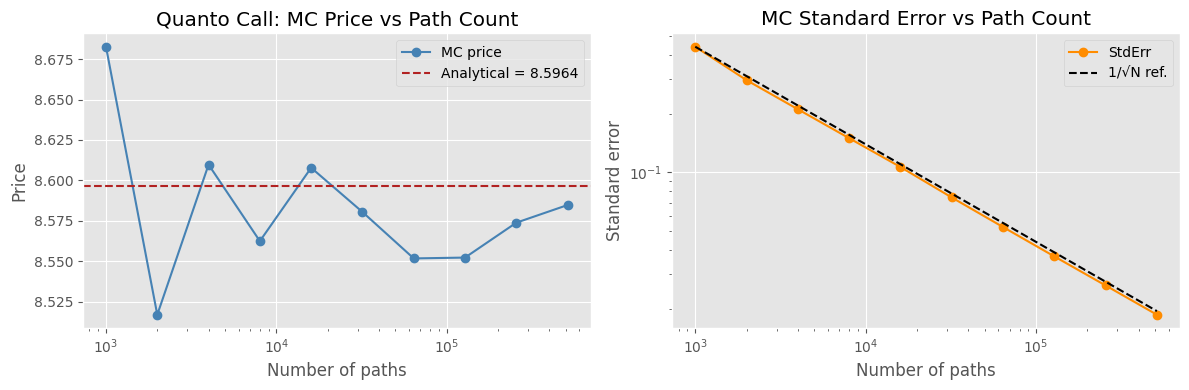

In [5]:
# MC convergence
path_counts = [1_000 * 2**i for i in range(10)]   # 1k → 512k
mc_prices, mc_errs = [], []
ana_call = qf.qEuroBS(1, spot, strike, T, rd, rf, q_div, sigma_S, sigma_Q, rho)

for n in path_counts:
    res = qf.qEuroBSMC(1, strike, T, spot, disc_yc, q_div, sigma_S,
                        mcparams, n, growth_yc, sigma_Q, rho)
    mc_prices.append(res['Mean'])
    mc_errs.append(res['StdErr'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(path_counts, mc_prices, 'o-', color='steelblue', label='MC price')
axes[0].axhline(ana_call, color='firebrick', linestyle='--', label=f'Analytical = {ana_call:.4f}')
axes[0].set_xscale('log')
axes[0].set_title('Quanto Call: MC Price vs Path Count')
axes[0].set_xlabel('Number of paths'); axes[0].set_ylabel('Price'); axes[0].legend()

ref_n = np.array(path_counts, dtype=float)
axes[1].loglog(path_counts, mc_errs, 'o-', color='darkorange', label='StdErr')
axes[1].loglog(path_counts, mc_errs[0] * np.sqrt(path_counts[0] / ref_n), 'k--', label='1/√N ref.')
axes[1].set_title('MC Standard Error vs Path Count')
axes[1].set_xlabel('Number of paths'); axes[1].set_ylabel('Standard error'); axes[1].legend()

plt.tight_layout()
plt.savefig("mc_convergence.png", dpi=150, bbox_inches="tight")
plt.show()


#### **PDE Pricing - `qf.qEuroBSPDE`**

In [6]:
# Zero Quanto Check + Base pricing
print(f"{'Type':>5s}  {'Analytical':>12s}  {'PDE':>12s}  {'Error':>10s}")
for phi, label in [(1, 'call'), (-1, 'put')]:
    ana = qf.qEuroBS(phi, spot, strike, T, rd, rf, q_div, sigma_S, sigma_Q, rho)
    pde = qf.qEuroBSPDE(phi, strike, T, spot, disc_yc, growth_yc,
                         q_div, sigma_S, sigma_Q, rho, pde_fine)
    print(f"{label:>5s}  {ana:>12.6f}  {pde['Price']:>12.6f}  {pde['Price']-ana:>+10.2e}")

# Zero-quanto consistency: rf=rd, rho=0  =>  must match plain euroBSPDE
plain  = qf.euroBSPDE(1, strike, T, spot, disc_yc, q_div, sigma_S, pde_fine)
zero_q = qf.qEuroBSPDE(1, strike, T, spot, disc_yc, disc_yc, q_div, sigma_S, 0.0, 0.0, pde_fine)
print(f'\nZero-quanto consistency check (r_f = r_d, ρ = 0):')
print(f'  plain euroBSPDE = {plain["Price"]:.6f}')
print(f'  qEuroBSPDE      = {zero_q["Price"]:.6f}')
print(f'  diff            = {zero_q["Price"] - plain["Price"]:+.2e}')


 Type    Analytical           PDE       Error
 call      8.596437      8.595850   -5.87e-04
  put      6.771823      6.771235   -5.87e-04

Zero-quanto consistency check (r_f = r_d, ρ = 0):
  plain euroBSPDE = 9.226424
  qEuroBSPDE      = 9.226424
  diff            = +0.00e+00


Analytical call = 8.596437

      Grid         Price         Error
 50×50           8.559873     -3.66e-02
100×100          8.587166     -9.27e-03
200×200          8.594100     -2.34e-03
400×400          8.595850     -5.87e-04
800×800          8.596290     -1.47e-04


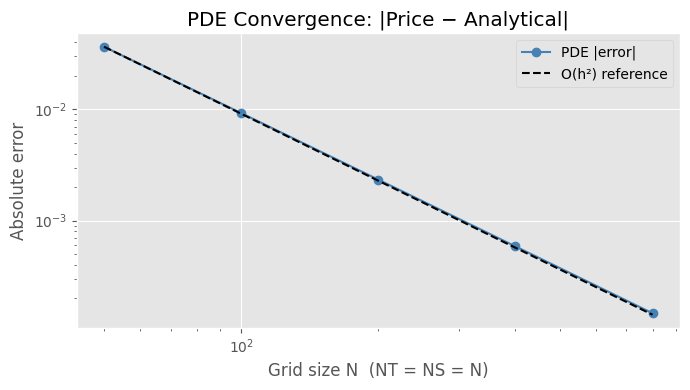

In [7]:
# PDE Convergence
grids = [50, 100, 200, 400, 800]
pde_prices, pde_abs_errs = [], []
ana_call = qf.qEuroBS(1, spot, strike, T, rd, rf, q_div, sigma_S, sigma_Q, rho)

print(f"Analytical call = {ana_call:.6f}\n")
print(f"{'Grid':>10s}  {'Price':>12s}  {'Error':>12s}")
for n in grids:
    p   = {'NTIMESTEPS': n, 'NSPOTNODES': n, 'NSTDDEVS': 5, 'THETA': 0.5}
    res = qf.qEuroBSPDE(1, strike, T, spot, disc_yc, growth_yc, q_div, sigma_S, sigma_Q, rho, p)
    err = res['Price'] - ana_call
    pde_prices.append(res['Price']); pde_abs_errs.append(abs(err))
    print(f"{n:>3d}×{n:<3d}      {res['Price']:>12.6f}  {err:>+12.2e}")

fig, ax = plt.subplots(figsize=(7, 4))
h = np.array(grids, dtype=float)
ax.loglog(grids, pde_abs_errs, 'o-', color='steelblue', label='PDE |error|')
ax.loglog(grids, pde_abs_errs[0] * (grids[0] / h)**2, 'k--', label='O(h²) reference')
ax.set_title('PDE Convergence: |Price − Analytical|')
ax.set_xlabel('Grid size N  (NT = NS = N)'); ax.set_ylabel('Absolute error'); ax.legend()
plt.tight_layout()
plt.savefig("pde_convergence.png", dpi=150, bbox_inches="tight")
plt.show()


#### **Three-Way Comparison: Strike Sweep**
All three methods across K ∈ {80, 90, 100, 110, 120}, calls and puts.


In [8]:
strikes_sweep = [80, 90, 100, 110, 120]
npaths_cmp    = 200_000

print(f"{'K':>5s}  {'Type':>5s}  {'Analytical':>12s}  {'MC Mean':>10s}  "
      f"{'MC StdErr':>10s}  {'PDE':>12s}  {'PDE err':>10s}")
for K in strikes_sweep:
    for phi, lbl in [(1, 'call'), (-1, 'put')]:
        ana = qf.qEuroBS(phi, spot, K, T, rd, rf, q_div, sigma_S, sigma_Q, rho)
        mc  = qf.qEuroBSMC(phi, K, T, spot, disc_yc, q_div, sigma_S,
                            mcparams, npaths_cmp, growth_yc, sigma_Q, rho)
        pde = qf.qEuroBSPDE(phi, K, T, spot, disc_yc, growth_yc,
                             q_div, sigma_S, sigma_Q, rho, pde_fine)
        print(f"{K:>5d}  {lbl:>5s}  {ana:>12.6f}  {mc['Mean']:>10.6f}  "
              f"{mc['StdErr']:>10.6f}  {pde['Price']:>12.6f}  {pde['Price']-ana:>+10.2e}")


    K   Type    Analytical     MC Mean   MC StdErr           PDE     PDE err
   80   call     21.788787   21.763635    0.040618     21.788878   +9.10e-05
   80    put      0.939583    0.929765    0.007003      0.939674   +9.10e-05
   90   call     14.294652   14.260479    0.036063     14.294254   -3.98e-04
   90    put      2.957743    2.938904    0.013475      2.957345   -3.98e-04
  100   call      8.596437    8.556865    0.029687      8.595850   -5.87e-04
  100    put      6.771823    6.747584    0.021036      6.771235   -5.87e-04
  110   call      4.759915    4.725877    0.022757      4.759435   -4.81e-04
  110    put     12.447595   12.428890    0.028213     12.447114   -4.81e-04
  120   call      2.448609    2.424936    0.016438      2.448740   +1.32e-04
  120    put     19.648582   19.640243    0.033981     19.648714   +1.32e-04


In [9]:
q_fwd  = qf.qFwdPrice(spot=spot, timetoexp=T, intrate=rf,
                       divyield=q_div, assetvol=sigma_S, fxvol=sigma_Q, correl=rho)
df_d   = qf.discount(disc_yc, T)
disc_f = df_d * q_fwd

print(f'Quanto forward F^Q(0,T)   = {q_fwd:.6f}')
print(f'Discount factor e^(-rd T) = {df_d:.6f}')
print(f'Discounted quanto forward  = {disc_f:.6f}\n')

print(f"{'K':>8s}  {'C^Q':>12s}  {'C^Q − disc.F^Q':>18s}")
for K in [80, 50, 20, 5, 1, 0.1, 0.01]:
    c = qf.qEuroBS(1, spot, K, T, rd, rf, q_div, sigma_S, sigma_Q, rho)
    print(f'{K:8.3f}  {c:12.6f}  {c - disc_f:18.6f}')


Quanto forward F^Q(0,T)   = 101.918165
Discount factor e^(-rd T) = 0.951229
Discounted quanto forward  = 96.947557

       K           C^Q      C^Q − disc.F^Q
  80.000     21.788787          -75.158771
  50.000     49.386706          -47.560851
  20.000     77.922969          -19.024588
   5.000     92.191410           -4.756147
   1.000     95.996328           -0.951229
   0.100     96.852434           -0.095123
   0.010     96.938045           -0.009512


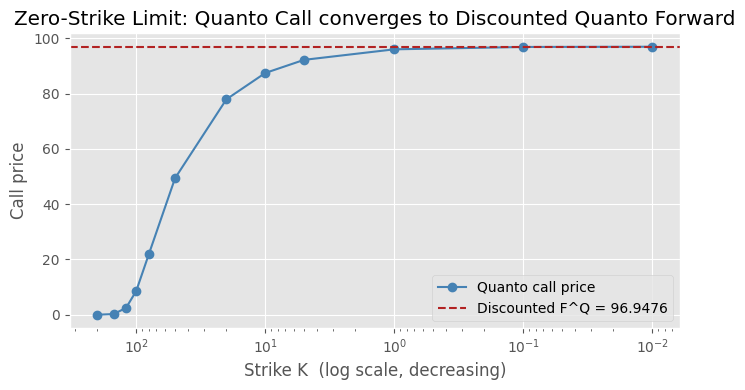

In [10]:
# Zero-strike limit: visual — quanto call converges to discounted F^Q as K -> 0
K_vals  = [200, 150, 120, 100, 80, 50, 20, 10, 5, 1, 0.1, 0.01]
call_zs = [qf.qEuroBS(1, spot, K, T, rd, rf, q_div, sigma_S, sigma_Q, rho) for K in K_vals]

disc_fwd = qf.discount(disc_yc, T) * qf.qFwdPrice(
    spot=spot, timetoexp=T, intrate=rf,
    divyield=q_div, assetvol=sigma_S, fxvol=sigma_Q, correl=rho)

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogx(K_vals, call_zs, 'o-', color='steelblue', label='Quanto call price')
ax.axhline(disc_fwd, color='firebrick', linestyle='--',
           label=f'Discounted F^Q = {disc_fwd:.4f}')
ax.set_xlabel('Strike K  (log scale, decreasing)')
ax.set_ylabel('Call price')
ax.set_title('Zero-Strike Limit: Quanto Call converges to Discounted Quanto Forward')
ax.invert_xaxis()
ax.legend()
plt.tight_layout()
plt.savefig('zero_strike_limit.png', dpi=150, bbox_inches='tight')
plt.show()

#### **Call-Put Parity**

In [11]:
# Parity Strike Check
q_fwd = qf.qFwdPrice(spot=spot, timetoexp=T, intrate=rf,
                      divyield=q_div, assetvol=sigma_S, fxvol=sigma_Q, correl=rho)
df_d  = qf.discount(disc_yc, T)

print(f'F^Q = {q_fwd:.6f},  e^(-rd T) = {df_d:.6f}\n')
print(f"{'K':>5s}  {'C^Q':>10s}  {'P^Q':>10s}  {'C-P':>10s}  {'df*(F^Q-K)':>12s}  {'Error':>12s}")
for K in [80, 90, 100, 110, 120]:
    C   = qf.qEuroBS(1,  spot, K, T, rd, rf, q_div, sigma_S, sigma_Q, rho)
    P   = qf.qEuroBS(-1, spot, K, T, rd, rf, q_div, sigma_S, sigma_Q, rho)
    rhs = df_d * (q_fwd - K)
    err = (C - P) - rhs
    print(f"{K:>5d}  {C:>10.6f}  {P:>10.6f}  {C-P:>10.6f}  {rhs:>12.6f}  {err:>+12.2e}")


F^Q = 101.918165,  e^(-rd T) = 0.951229

    K         C^Q         P^Q         C-P    df*(F^Q-K)         Error
   80   21.788787    0.939583   20.849203     20.849203     +3.55e-15
   90   14.294652    2.957743   11.336909     11.336909     +0.00e+00
  100    8.596437    6.771823    1.824615      1.824615     -6.88e-15
  110    4.759915   12.447595   -7.687679     -7.687679     +0.00e+00
  120    2.448609   19.648582  -17.199974    -17.199974     +1.07e-14


In [12]:
# Parity Maturity Check
qf.mktClear()
t_mats = [0.25, 0.5, 1.0, 2.0, 5.0, 10.0]
qf.ycCreate(ycname='DISC',   tmats=t_mats, vals=[rd]*len(t_mats), valtype=0)
qf.ycCreate(ycname='GROWTH', tmats=t_mats, vals=[rf]*len(t_mats), valtype=0)

print(f"{'T':>5s}  {'C^Q':>10s}  {'P^Q':>10s}  {'C-P':>10s}  {'df*(F^Q-K)':>12s}  {'Error':>12s}")
for t in [0.25, 0.5, 1.0, 2.0, 5.0]:
    fwd_t = qf.qFwdPrice(spot=spot, timetoexp=t, intrate=rf,
                          divyield=q_div, assetvol=sigma_S, fxvol=sigma_Q, correl=rho)
    df_t  = qf.discount('DISC', t)
    C = qf.qEuroBS(1,  spot, strike, t, rd, rf, q_div, sigma_S, sigma_Q, rho)
    P = qf.qEuroBS(-1, spot, strike, t, rd, rf, q_div, sigma_S, sigma_Q, rho)
    rhs = df_t * (fwd_t - strike)
    err = (C - P) - rhs
    print(f"{t:>5.2f}  {C:>10.6f}  {P:>10.6f}  {C-P:>10.6f}  {rhs:>12.6f}  {err:>+12.2e}")


    T         C^Q         P^Q         C-P    df*(F^Q-K)         Error
 0.25    4.187156    3.716941    0.470215      0.470215     +6.61e-15
 0.50    6.002173    5.071214    0.930959      0.930959     +6.77e-15
 1.00    8.596437    6.771823    1.824615      1.824615     -6.88e-15
 2.00   12.218246    8.713699    3.504547      3.504547     +6.66e-15
 5.00   18.666702   10.905263    7.761439      7.761439     -2.31e-14


#### **Correlation Check**

In [13]:
qf.mktClear()
qf.ycCreate(ycname='DISC',   tmats=[1, 5, 10], vals=[rd, rd, rd], valtype=0)
qf.ycCreate(ycname='GROWTH', tmats=[1, 5, 10], vals=[rf, rf, rf], valtype=0)

rho_vals   = np.linspace(-0.9, 0.9, 19)
npaths_cor = 200_000
ana_calls, ana_puts, mc_calls, pde_calls = [], [], [], []

for r in rho_vals:
    ca  = qf.qEuroBS(1,  spot, strike, T, rd, rf, q_div, sigma_S, sigma_Q, r)
    pa  = qf.qEuroBS(-1, spot, strike, T, rd, rf, q_div, sigma_S, sigma_Q, r)
    mc  = qf.qEuroBSMC(1, strike, T, spot, 'DISC', q_div, sigma_S,
                        mcparams, npaths_cor, 'GROWTH', sigma_Q, r)
    pde = qf.qEuroBSPDE(1, strike, T, spot, 'DISC', 'GROWTH', q_div,
                         sigma_S, sigma_Q, r, pde_fine)
    ana_calls.append(ca); ana_puts.append(pa)
    mc_calls.append(mc['Mean']); pde_calls.append(pde['Price'])

print(f"{'rho':>6s}  {'Call(ana)':>11s}  {'Call(MC)':>11s}  {'Call(PDE)':>11s}  {'Put(ana)':>11s}")
for i in range(0, len(rho_vals), 3):
    print(f"{rho_vals[i]:>+6.2f}  {ana_calls[i]:>11.6f}  {mc_calls[i]:>11.6f}  "
          f"{pde_calls[i]:>11.6f}  {ana_puts[i]:>11.6f}")

mid   = len(rho_vals) // 2
swing = max(ana_calls) - min(ana_calls)
print(f'\nCall range: {min(ana_calls):.4f} – {max(ana_calls):.4f}  '
      f'(swing = {swing:.4f}, {swing/ana_calls[mid]*100:.1f}% of ρ=0 price)')


   rho    Call(ana)     Call(MC)    Call(PDE)     Put(ana)
 -0.90     6.738544     6.701788     6.737926     8.341967
 -0.60     7.173937     7.136445     7.173329     7.931885
 -0.30     7.628552     7.590366     7.627952     7.533382
 +0.00     8.102644     8.063722     8.102050     7.146642
 +0.30     8.596437     8.556865     8.595850     6.771823
 +0.60     9.110131     9.070407     9.109549     6.409050
 +0.90     9.643893     9.604191     9.643314     6.058422

Call range: 6.7385 – 9.6439  (swing = 2.9053, 35.9% of ρ=0 price)


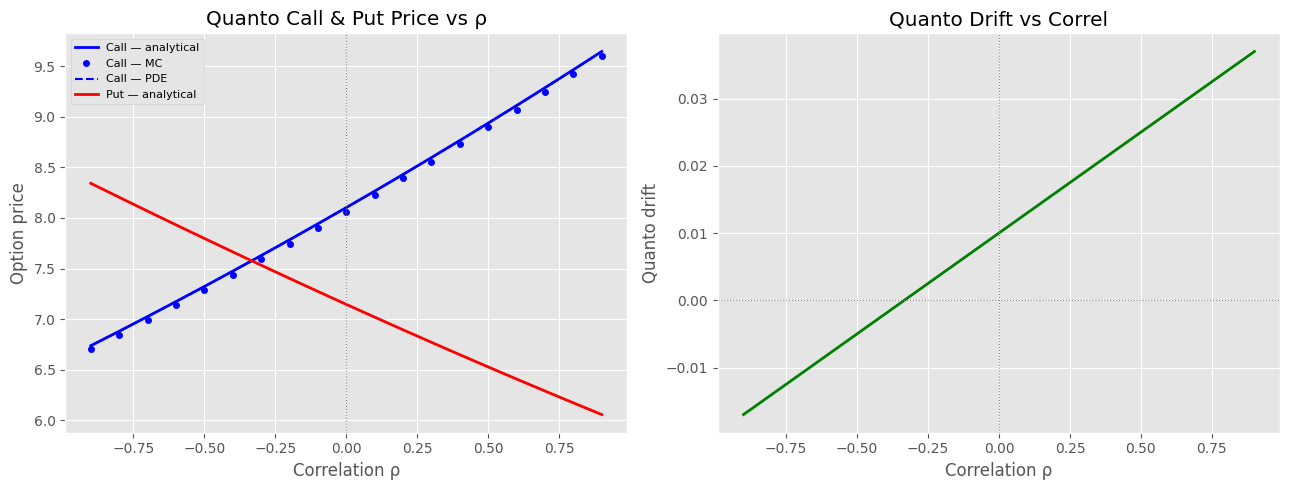

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(rho_vals, ana_calls, 'b-',  linewidth=2,  label='Call — analytical')
axes[0].plot(rho_vals, mc_calls,  'bo',  markersize=4, label='Call — MC')
axes[0].plot(rho_vals, pde_calls, 'b--', linewidth=1.5,label='Call — PDE')
axes[0].plot(rho_vals, ana_puts,  'r-',  linewidth=2,  label='Put — analytical')
axes[0].axvline(0, color='gray', linestyle=':', linewidth=0.8)
axes[0].set_xlabel('Correlation ρ')
axes[0].set_ylabel('Option price')
axes[0].set_title('Quanto Call & Put Price vs ρ')
axes[0].legend(fontsize=8)

drifts = [rf - q_div + r * sigma_S * sigma_Q for r in rho_vals]
axes[1].plot(rho_vals, drifts, 'g-', linewidth=2)
axes[1].axhline(0, color='gray', linestyle=':', linewidth=0.8)
axes[1].axvline(0, color='gray', linestyle=':', linewidth=0.8)
axes[1].set_xlabel('Correlation ρ')
axes[1].set_ylabel('Quanto drift')
axes[1].set_title('Quanto Drift vs Correl')

plt.tight_layout()
plt.savefig("correlation_effect.png", dpi=150, bbox_inches="tight")
plt.show()